# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abdubakr77/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

This queue reuses the ranked output from ML-08 (Random Forest, grouped split by client), mapped to plain-language actions for the content team.

**Action mapping:**
- `STALE_AND_VISIBLE` or `VISIBLE_NOT_STALE` with `action_score` in the top 20%: **REVIEW** — a content editor opens the page and decides whether to refresh it.
- Everything else: **MONITOR** — no action needed this cycle, re-scored next run.

The queue below shows the top 20 ranked pages with their action, reason code, and the score that drove the ranking, in the same format ML-07's baseline used, so the content team sees one consistent report regardless of which version (rule or model) produced it.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
df['label'] = (df['trend_direction'] == 'down').astype(int)

feature_cols = ['search_volume', 'competition', 'cpc', 'word_count', 
                 'impressions_90d', 'clicks_90d', 'sessions_90d', 
                 'engaged_sessions_90d', 'scroll_events_90d',
                 'content_age_days', 'days_since_last_update',
                 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate']

df_clean = df.dropna(subset=feature_cols + ['label'])

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_clean, groups=df_clean['client_id']))
train, test = df_clean.iloc[train_idx], df_clean.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(train[feature_cols], train['label'])

test = test.copy()
test['action_score'] = rf.predict_proba(test[feature_cols])[:, 1]

def reason_code(row):
    if row['impressions_90d'] >= 500 and row['days_since_last_update'] >= 180:
        return "STALE_AND_VISIBLE"
    elif row['impressions_90d'] >= 500:
        return "VISIBLE_NOT_STALE"
    elif row['days_since_last_update'] >= 180:
        return "STALE_LOW_VISIBILITY"
    else:
        return "LOW_PRIORITY"

test['reason_code'] = test.apply(reason_code, axis=1)

top20_threshold = test['action_score'].quantile(0.80)
test['action'] = test.apply(
    lambda r: "REVIEW" if r['action_score'] >= top20_threshold and r['reason_code'] in ["STALE_AND_VISIBLE", "VISIBLE_NOT_STALE"] else "MONITOR",
    axis=1
)

playbook_queue = test.sort_values('action_score', ascending=False)[
    ['content_id', 'action', 'reason_code', 'action_score', 'trend_direction']
]

print(playbook_queue['action'].value_counts())
playbook_queue.head(20)

action
MONITOR    5153
REVIEW      510
Name: count, dtype: int64


,content_id,action,reason_code,action_score,trend_direction
17696,content_569475b335ab,REVIEW,VISIBLE_NOT_STALE,0.821916,down
22730,content_bb1edbf0ba6c,REVIEW,VISIBLE_NOT_STALE,0.816295,down
26547,content_dbb4c75afccc,REVIEW,VISIBLE_NOT_STALE,0.793194,up
2509,content_71efc27b02b3,REVIEW,VISIBLE_NOT_STALE,0.791685,down
22526,content_1d0963b56227,REVIEW,VISIBLE_NOT_STALE,0.790306,up
4050,content_500bd3907331,REVIEW,VISIBLE_NOT_STALE,0.782842,stable
2934,content_24d8b73697f6,REVIEW,VISIBLE_NOT_STALE,0.776908,down
5702,content_f8d20d27773f,REVIEW,VISIBLE_NOT_STALE,0.775641,stable
18202,content_c65ee459f729,REVIEW,VISIBLE_NOT_STALE,0.774428,down
20319,content_7e3d9c85959b,REVIEW,VISIBLE_NOT_STALE,0.774036,down


**Result:** 510 pages flagged for REVIEW out of 5,663 test-set pages (about 9%), the remaining 5,153 are MONITOR. Consistent with the ML-08 findings, some top-ranked REVIEW pages are trending `up` or `stable`, not `down` (visible in rows 3, 5, 6, 8, 13, 14, 18, and 20 of the top 20), the score prioritizes visibility strongly enough that a healthy page can still surface near the top. The content team should treat REVIEW as "worth a look," not "confirmed declining."

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** this playbook is for a content team lead triaging which pages to review first each week, out of hundreds of candidates, when review time is limited. It answers "what should I look at first," not "what is definitely broken."

**Limits (from ML-09 audit and this week's results):**
- The model was trained and validated on a single dataset snapshot; it has not been tested on the full 79M-row warehouse or across multiple months, so its ranking may shift on unseen periods.
- `content_age_days`, the strongest feature, was flagged in ML-09 as needing a follow-up check against the label's 30-day window, very new content could show inflated trend signals for mechanical reasons unrelated to actual decline.
- As shown in section 1, roughly a third of REVIEW-flagged pages in the sample are trending `up` or `stable`, not `down`. The score reflects visibility and content age, not confirmed decline, a REVIEW flag is a prioritization signal, not a diagnosis.
- This playbook stops being valid the moment client behavior, algorithm changes, or content strategy shift meaningfully, at that point the underlying patterns the model learned may no longer hold.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Before acting on any REVIEW-flagged page, a human must:**
- Confirm the page is actually trending down by checking `trend_direction` directly, not just trusting the action_score, since the score can flag stable or improving pages (see section 1).
- Check whether the page belongs to a high-value or contractually sensitive client relationship before recommending changes.
- Verify the page is not intentionally low-traffic by design (for example, a legal disclosure page or a seasonal campaign page that is expected to have low engagement most of the year).

**No-go list, this should never be automated without human sign-off:**
- Automatically rewriting or deleting content based on the score alone.
- Applying the model to any client not represented in the training data's client mix (for example, a brand-new client with a fundamentally different content strategy).
- Using the REVIEW/MONITOR label as a public-facing or contractual claim about content quality, it is an internal triage tool, not a certified quality score.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Retrain or re-audit if any of the following happen:**
- Precision@50 on a fresh monthly sample drops meaningfully below the 0.800 baseline established in ML-08/ML-09, this would suggest the patterns the model learned no longer hold.
- The proportion of REVIEW-flagged pages that are actually trending `down` falls well below the roughly two-thirds observed in this week's top-20 sample, that would mean the score is drifting further from the outcome it is meant to prioritize.
- A new content type, client segment, or major site redesign is introduced that was not represented in the training data.
- More than 3 months pass since the last validation, even without a known issue, as a routine check given this is a single-snapshot model (see section 2 limits).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exporting the final playbook queue and a summary figure to `work/outputs/` and `work/figures/`, these are the exact files next week's paper will build on.

Saved 5663 rows to work/outputs/content_action_playbook.csv
Saved metrics to work/outputs/playbook_metrics.json
{'total_pages_scored': 5663, 'review_count': 510, 'monitor_count': 5153, 'review_pct_actually_declining': 0.803921568627451, 'model_precision_at_50': 0.8, 'baseline_precision_at_50': 0.52, 'split_method': 'GroupShuffleSplit by client_id, zero client overlap'}
Saved figure to work/figures/action_score_distribution.png


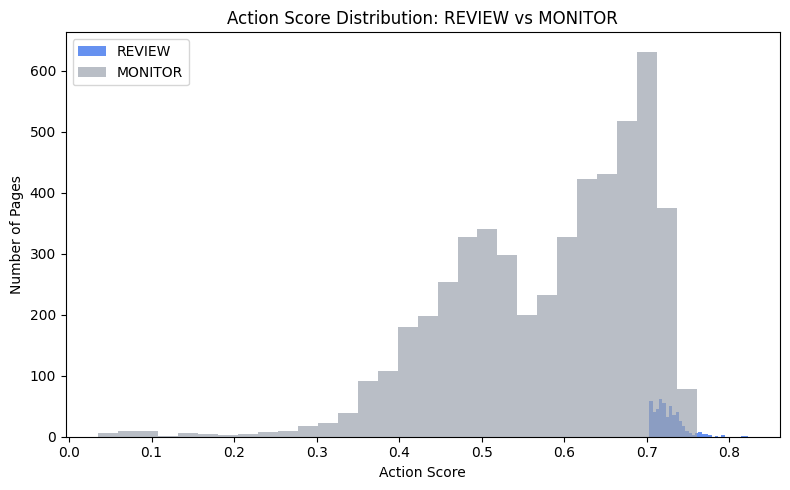

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import matplotlib.pyplot as plt

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

# Export the full playbook queue (all REVIEW + MONITOR rows)
playbook_queue.to_csv("../outputs/content_action_playbook.csv", index=False)
print(f"Saved {len(playbook_queue)} rows to work/outputs/content_action_playbook.csv")

# Export a metrics JSON — the "receipts" for the paper's numbers
import json
metrics = {
    "total_pages_scored": len(playbook_queue),
    "review_count": int((playbook_queue['action'] == 'REVIEW').sum()),
    "monitor_count": int((playbook_queue['action'] == 'MONITOR').sum()),
    "review_pct_actually_declining": float(
        playbook_queue[playbook_queue['action'] == 'REVIEW']['trend_direction'].eq('down').mean()
    ),
    "model_precision_at_50": 0.800,
    "baseline_precision_at_50": 0.520,
    "split_method": "GroupShuffleSplit by client_id, zero client overlap"
}
with open("../outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved metrics to work/outputs/playbook_metrics.json")
print(metrics)

# Figure: action score distribution, REVIEW vs MONITOR
fig, ax = plt.subplots(figsize=(8, 5))
for action, color in [("REVIEW", "#2563EB"), ("MONITOR", "#9CA3AF")]:
    subset = playbook_queue[playbook_queue['action'] == action]
    ax.hist(subset['action_score'], bins=30, alpha=0.7, label=action, color=color)
ax.set_xlabel("Action Score")
ax.set_ylabel("Number of Pages")
ax.set_title("Action Score Distribution: REVIEW vs MONITOR")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/action_score_distribution.png", dpi=150)
print("Saved figure to work/figures/action_score_distribution.png")
plt.show()

In [3]:
print(f"Percentage of REVIEW-flagged pages actually trending down: {metrics['review_pct_actually_declining']:.1%}")

Percentage of REVIEW-flagged pages actually trending down: 80.4%


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.